<a href="https://colab.research.google.com/github/Uhurua/Intro-To-Machine-Learning-Class-2026/blob/main/Unit_4_ML_Logistic_Regression_Class_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset Analysis

From Kaggle: The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

# Tasks:



1.   Every step must have an explanation
2.   Every plot/ chart must have an iterpretation
3.   Add your observations for each section
4.   Draw clear conclusions (at least 5 conclusions)



This cell is used to use import the wide well known tool used to structure the titanic information. PD is used to load the information from the titanic data

In [9]:
import pandas as pd

I had to turn the Train=Pd. into a text cell because it wasnt running because it wasnt python under the code cell. I had to change it to a text cell.
---



*   List item
*   List item



In [10]:
train = pd.read_csv('https://raw.githubusercontent.com/niteen11/data301_predictive_analytics_machine_learning/main/data/titanic_train.csv')

Train is the name of the data set. Train head is the code to put the data into rows without printing the full data set.

In [11]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA (Exploratory Data Analysis)

In [12]:
import seaborn as sns

Seaborn is an library in python that makes interactive visualization more appealing. Matplot provides the basic structure so they work togther.

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt

we are using sea born to make the heat map. Train.isnull makes the color grid for all things that are positive. Y tick takes away the y axis, Cbar false hides the color bar. Cmpa viridis is one of the popular choices to color the graph

<Axes: >

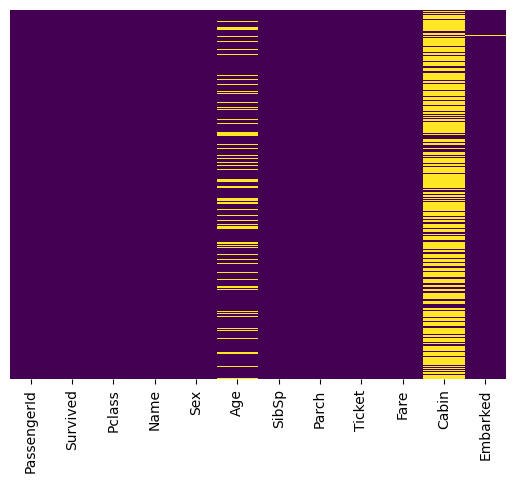

In [14]:
sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')

## Class


Sns set style creates the grapth with the white grid. The sns counter plottakes on the data for the people who survived.

<Axes: xlabel='Survived', ylabel='count'>

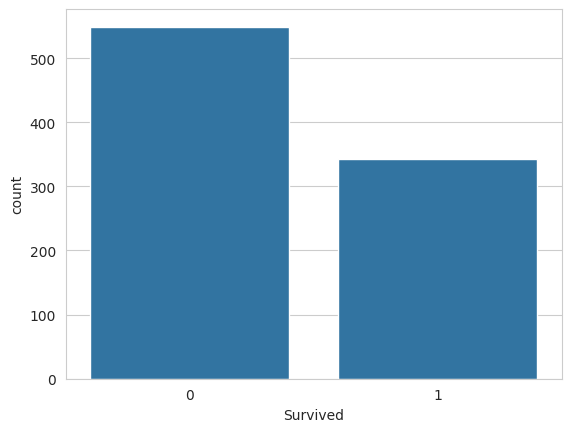

In [15]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', data=train)

## Survived

This is the sam econcept now are using binary information to show the results between man and women

<Axes: xlabel='Survived', ylabel='count'>

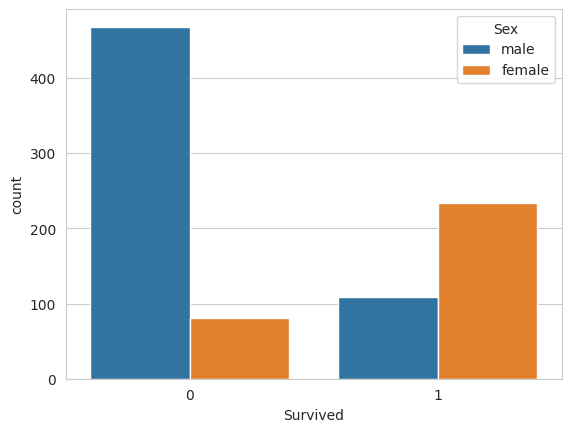

In [16]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Sex', data=train)

Eveyrything is the same. The Hue makes every piece of data from P class different colors.

<Axes: xlabel='Survived', ylabel='count'>

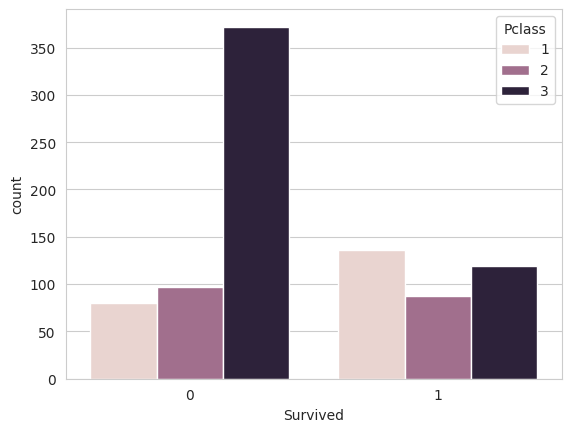

In [17]:
sns.set_style('whitegrid')
sns.countplot(x='Survived', hue='Pclass', data=train)

## Age

Seaborn displot creates a histogram. Train age make columbs for the data using age. The dropna removes the data where the age value is missing. KDE false removes the histogram line that comes with it. Bins create data using 30 lines to represent the outcome.

/tmp/ipykernel_4775/65184067.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde=False, bins=30)


<Axes: xlabel='Age'>

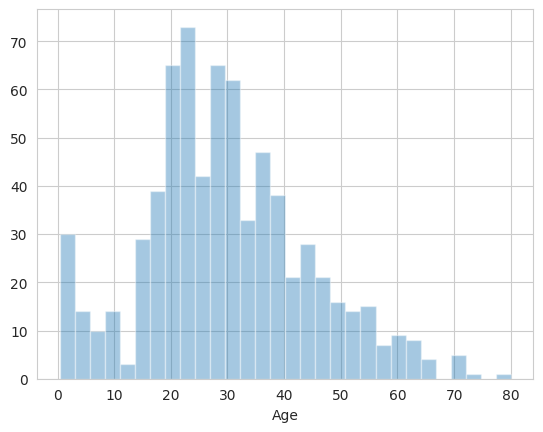

In [18]:
sns.distplot(train['Age'].dropna(), kde=False, bins=30)

## Siblings

This represents the amount of siblings of each family. y axis is the amount of people.

<Axes: xlabel='SibSp', ylabel='count'>

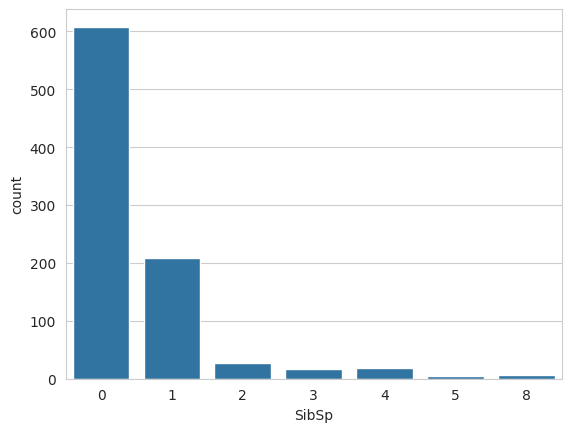

In [19]:
sns.countplot(x='SibSp',data=train)

# Data Cleaning and Data Pre - Processing

We are dropping the column of cabin. Axis 1 is for a  column not a row. 0 is a row.

In [20]:
train.drop('Cabin', axis=1, inplace= True)

In [21]:
train.dropna(inplace=True)

We are creating columns for all of the categories below "this was Pd get dummies is. Train Sex makes columns forr male and femals putting drop first combines male and female.

In [22]:
sex = pd.get_dummies(train['Sex'], drop_first=True)
embark = pd.get_dummies(train['Embarked'], drop_first=True)

Train dropped all of these categories. With axis we are removing the colum not the rows. In place modifies the original data not new data.

In [23]:
train.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace= True)

In [24]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500


In [25]:
train = pd.concat([train, sex, embark],axis=1)

We are taking the original data and we are comining the information we removed previously to create a new column. The New colums include males and the places they derived from Q is a place and S is a place.No women column because we are able distingusih with just a men column.

In [26]:
train.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,0,3,22.0,1,0,7.2500,True,False,True
1,2,1,1,38.0,1,0,71.2833,False,False,False
2,3,1,3,26.0,0,0,7.9250,False,False,True
3,4,1,1,35.0,1,0,53.1000,False,False,True
4,5,0,3,35.0,0,0,8.0500,True,False,True


# Model building

We are importing a function from Sk learn to create a testing split which includes Testing and Training the model

In [27]:
from sklearn.model_selection import train_test_split

This is where we are using the four variable splits. We are the takign the train and test data and organizing them in the variables to the left. 70% for X Train, 30% for X test. Same for the Y. We dropped the old survived colum and made a new one. Test size is 30%. The random state makes sure we are running the same code over and over.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived',axis=1), train['Survived'],test_size=0.3, random_state=101)

We imported the sk learn model, we ompoted a logistic model. The Log model will use a blamk logistic regression model.

In [29]:
from sklearn.linear_model import LogisticRegression

In [30]:
logmodel = LogisticRegression()

We took our train information and formed our model using information from X and Y.

In [31]:
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Predict is taking new features which is data and use the linear progression mode to use information from the new tested data from the train models

In [39]:
predict = logmodel.predict(X_test)

## Classification report

In [33]:
from sklearn.metrics import classification_report

We added a metrics report from sklearn. The print classification report is testing Y because its the Stating amount that survived and did not.

Precision: Clasifies if its negative or positive

Recall: ability to find all positive samples

F-1 Score:Providing an average score

Support: Are occcurances, of how many people survived and didnt survive. 128 didnt survuve 86 did

In [3]:
print(classification_report(y_test,predict))

NameError: name 'classification_report' is not defined

## Confusion Matrix

We transported from sklearn metrixs and used import confusion matrix: It creates a 2x2 data set and compares the two values . The two values are people who survived and did not survive (Y test) . Predict is now the information from our tested model.

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, predict))

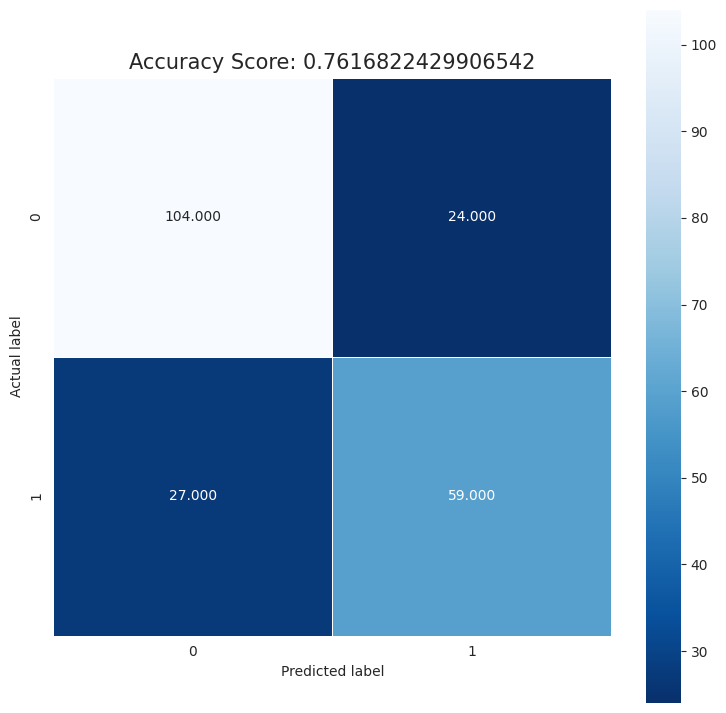

In [36]:
plt.figure(figsize=(9,9))
sns.heatmap(confusion_matrix(y_test, predict), annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(logmodel.score(X_test, y_test))
plt.title(all_sample_title, size = 15);

In [37]:
from sklearn import  metrics

Observation: Based on the information provided. The testing of the model we used was pretty accurate.

# Conclusion... Based on the information provided, The testing of the model we used was pretty accurate. The predictions were pretty stabel. The testing of the 70/30 was efficent. The figure used at the end with the 2 by 2 Matrix figure was very understanding. The sklearn graphs and SNS graphs were very useful as well.